# Grounding DINO single-image inference

This Colab notebook runs the repository's Grounding DINO detector on one Mars image. It uses the same prompt and thresholds as `crater_detection/grounded_sam.py` so its proposed boxes can be compared with the detections from the SAM 3 single-image notebook.

In [ ]:
import sys

!{sys.executable} -m pip install -q -U \
    "transformers" \
    "Pillow==11.3.0" \
    "matplotlib"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 43.7 MB/s eta 0:00:00
Installation complete. Restart the Colab runtime before running the next cell.


In [2]:
from pathlib import Path
from google.colab import files

uploaded = files.upload()
if not uploaded:
    raise ValueError("Upload one image to continue.")

image_path = Path(next(iter(uploaded)))
print(f"Selected image: {image_path}")

Saving lat_-2.0_long_-28.0_original.png to lat_-2.0_long_-28.0_original (1).png
Selected image: lat_-2.0_long_-28.0_original (1).png


In [3]:
import torch
from PIL import Image
from transformers import AutoModelForZeroShotObjectDetection, AutoProcessor

grounding_model_id = "IDEA-Research/grounding-dino-base"
text_labels = [["circle"]]
box_threshold = 0.30
text_threshold = 0.25
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")
processor = AutoProcessor.from_pretrained(grounding_model_id)
grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    grounding_model_id
).to(device)

Using device: cuda


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.74k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  933MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

In [4]:
from PIL import Image
import numpy as np

image_pil = Image.open(image_path).convert("RGB")
image_rgb = np.asarray(image_pil)

inputs = processor(
    images=image_pil,
    text=text_labels,
    return_tensors="pt",
).to(device)
with torch.no_grad():
    outputs = grounding_model(**inputs)

result = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=box_threshold,
    text_threshold=text_threshold,
    target_sizes=[image_pil.size[::-1]],
)[0]
boxes = result["boxes"].detach().cpu().numpy()
scores = result["scores"].detach().cpu().numpy()
labels = result["labels"]

print(f"Grounding DINO detections: {len(boxes)}")

Grounding DINO detections: 11


/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:89: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


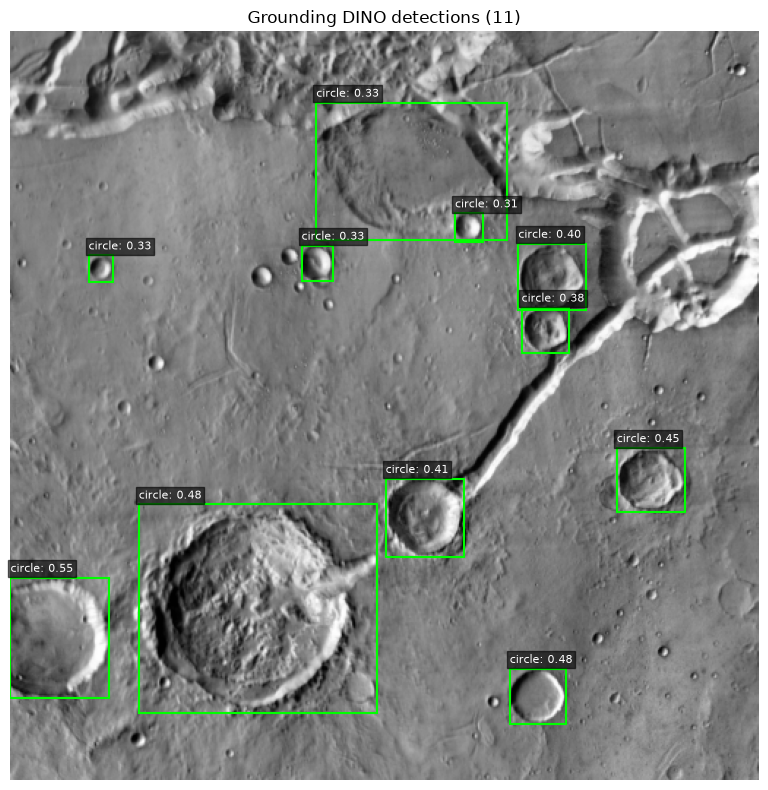

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, axis = plt.subplots(figsize=(12, 8))
axis.imshow(image_rgb)
for box, score, label in zip(boxes, scores, labels):
    x_min, y_min, x_max, y_max = box
    axis.add_patch(Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=False,
        edgecolor="lime",
        linewidth=1.5,
    ))
    axis.text(
        x_min,
        max(0, y_min - 4),
        f"{label}: {score:.2f}",
        color="white",
        fontsize=8,
        bbox={"facecolor": "black", "alpha": 0.6, "pad": 2},
    )
axis.set_title(f"Grounding DINO detections ({len(boxes)})")
axis.axis("off")
plt.tight_layout()
plt.show()

## Comparison notes

This notebook shows the boxes produced directly by Grounding DINO for the repository's `circle` prompt. Compare these proposed boxes with the detections produced by SAM 3 on the same image.